# Segmentación de estudiantes e-learning

Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("elearning_kmeans.csv")
df.head()


,horas_estudio_semana,videos_vistos,tests_realizados,dias_conectado_mes,interacciones_foro
0,10.743416,44,36,7,4
1,8.227006,61,20,15,5
2,6.044416,82,24,5,6
3,9.571243,28,5,6,9
4,8.983875,59,28,13,3


EDA

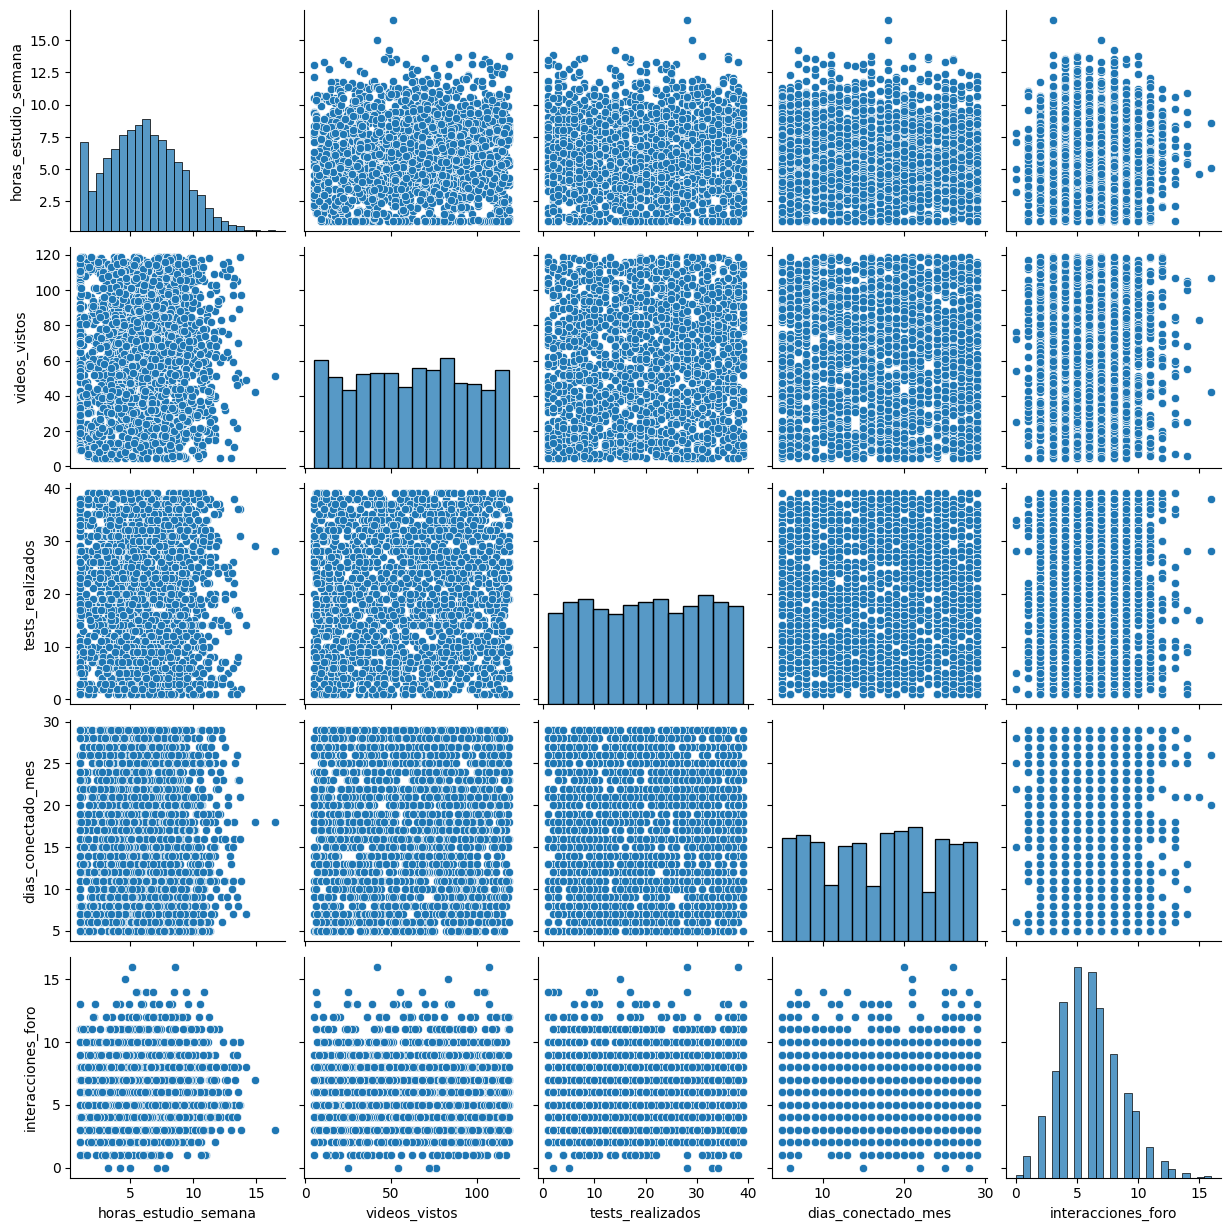

In [4]:
df.describe()
sns.pairplot(df)



Escalar

In [5]:
from sklearn.preprocessing import StandardScaler

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Método del codo

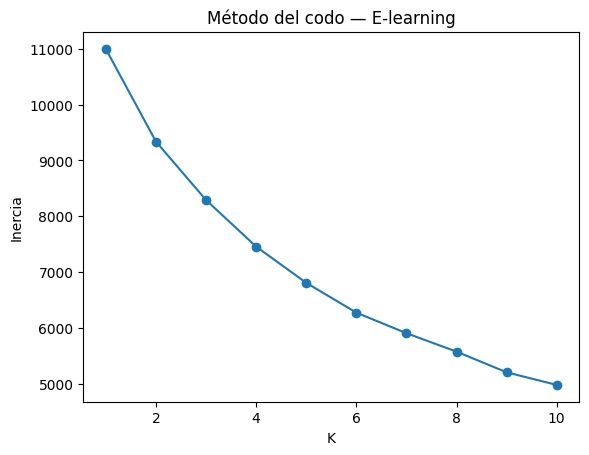

In [6]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo — E-learning")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.show()



KMeans

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)


Interpretación

In [8]:
df.groupby("cluster").mean()


,horas_estudio_semana,videos_vistos,tests_realizados,dias_conectado_mes,interacciones_foro
cluster,,,,,
0,6.775677,45.548276,30.886207,13.405172,6.758621
1,5.595283,32.111111,12.411111,20.848148,5.788889
2,5.442498,90.578671,23.807692,22.779720,5.428322
3,6.398209,77.911417,11.940945,10.446850,6.179134


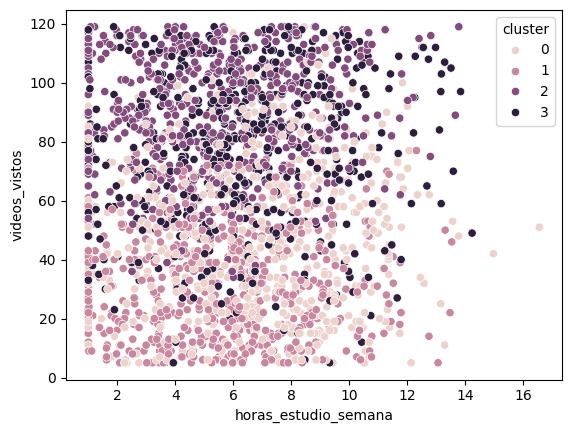

In [9]:
sns.scatterplot(data=df, x="horas_estudio_semana", y="videos_vistos", hue="cluster")
plt.show()




In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["cluster"])
print("Silhouette Score:", score)


Silhouette Score: 0.15187242638314832
